<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW5/hw5_problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 601 - Homework 5, Problem 1
## Decision Tree Classifiers on the Penguins Dataset

In [ ]:
!pip install palmerpenguins scikit-learn seaborn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from palmerpenguins import load_penguins
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42

## 1. Load and Preprocess the Dataset

In [3]:
# Load dataset
df = load_penguins()
print(f"Dataset shape (before cleaning): {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# Drop rows with missing values
df.dropna(inplace=True)
print(f"\nDataset shape (after cleaning): {df.shape}")
print(f"\nSpecies distribution:\n{df['species'].value_counts()}")
print(f"\nSex distribution:\n{df['sex'].value_counts()}")
df.head()

Dataset shape (before cleaning): (344, 8)
Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Dataset shape (after cleaning): (333, 8)

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Sex distribution:
sex
male      168
female    165
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [4]:
# Encode categorical features as integers
le_island  = LabelEncoder()
le_sex     = LabelEncoder()
le_species = LabelEncoder()

df['island_enc']  = le_island.fit_transform(df['island'])
df['sex_enc']     = le_sex.fit_transform(df['sex'])
df['species_enc'] = le_species.fit_transform(df['species'])

print("Island encoding :", dict(zip(le_island.classes_,  range(len(le_island.classes_)))))
print("Sex encoding    :", dict(zip(le_sex.classes_,     range(len(le_sex.classes_)))))
print("Species encoding:", dict(zip(le_species.classes_, range(len(le_species.classes_)))))

# Feature set (physical measurements + island; 'year' excluded as non-informative)
FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_enc']
X = df[FEATURES]

Island encoding : {'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}
Sex encoding    : {'female': 0, 'male': 1}
Species encoding: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}


## 2. Decision Tree — Species Classification

In [5]:
# Train / test split (stratified)
y_species = df['species_enc']
X_train, X_test, y_train, y_test = train_test_split(
    X, y_species, test_size=0.2, random_state=SEED, stratify=y_species
)

# Train full decision tree (default hyperparameters)
dt_species = DecisionTreeClassifier(random_state=SEED)
dt_species.fit(X_train, y_train)
y_pred_species = dt_species.predict(X_test)

print("=" * 50)
print("SPECIES CLASSIFIER — Full Tree")
print("=" * 50)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Accuracy         : {accuracy_score(y_test, y_pred_species):.4f}")
print(f"Number of leaves : {dt_species.get_n_leaves()}")
print(f"Tree depth       : {dt_species.get_depth()}")
print()
print(classification_report(y_test, y_pred_species, target_names=le_species.classes_))

SPECIES CLASSIFIER — Full Tree
Training samples : 266
Test samples     : 67
Accuracy         : 0.9552
Number of leaves : 11
Tree depth       : 5

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



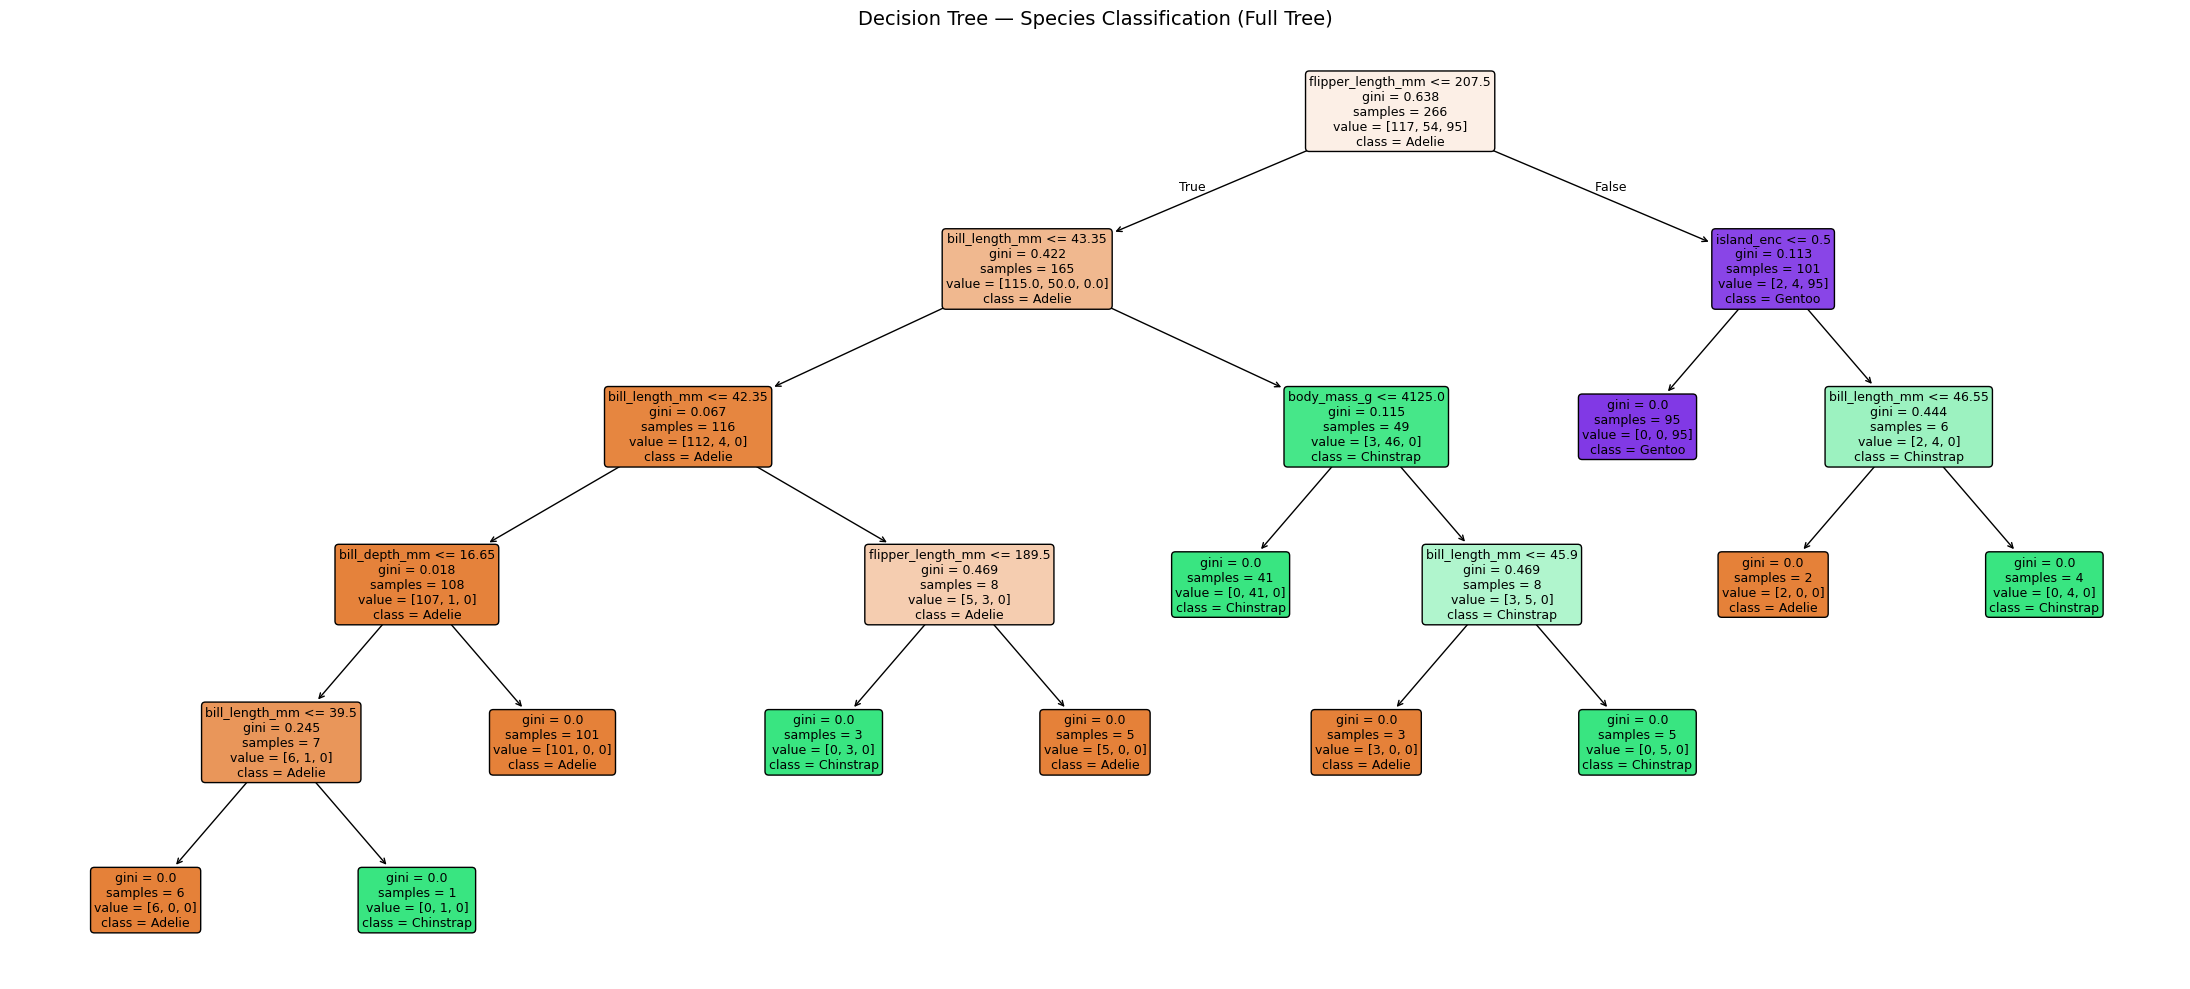

In [6]:
# Visualise the full species tree
plt.figure(figsize=(22, 10))
plot_tree(
    dt_species,
    feature_names=FEATURES,
    class_names=le_species.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Species Classification (Full Tree)", fontsize=14)
plt.tight_layout()
plt.show()

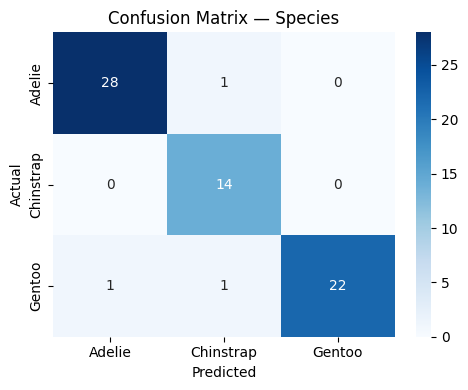

In [7]:
# Confusion matrix — Species
cm = confusion_matrix(y_test, y_pred_species)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_species.classes_, yticklabels=le_species.classes_)
plt.title("Confusion Matrix — Species")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
# Text-format tree rules — species
print("Species Decision Tree Rules:")
print(export_text(dt_species, feature_names=FEATURES))

Species Decision Tree Rules:
|--- flipper_length_mm <= 207.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.35
|   |   |   |--- bill_depth_mm <= 16.65
|   |   |   |   |--- bill_length_mm <= 39.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- bill_length_mm >  39.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- bill_depth_mm >  16.65
|   |   |   |   |--- class: 0
|   |   |--- bill_length_mm >  42.35
|   |   |   |--- flipper_length_mm <= 189.50
|   |   |   |   |--- class: 1
|   |   |   |--- flipper_length_mm >  189.50
|   |   |   |   |--- class: 0
|   |--- bill_length_mm >  43.35
|   |   |--- body_mass_g <= 4125.00
|   |   |   |--- class: 1
|   |   |--- body_mass_g >  4125.00
|   |   |   |--- bill_length_mm <= 45.90
|   |   |   |   |--- class: 0
|   |   |   |--- bill_length_mm >  45.90
|   |   |   |   |--- class: 1
|--- flipper_length_mm >  207.50
|   |--- island_enc <= 0.50
|   |   |--- class: 2
|   |--- island_enc >  0.50
|   |   |--- bill_length_mm <

## 3. Decision Tree — Sex Classification

In [9]:
y_sex = df['sex_enc']
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_sex, test_size=0.2, random_state=SEED, stratify=y_sex
)

dt_sex = DecisionTreeClassifier(random_state=SEED)
dt_sex.fit(X_train2, y_train2)
y_pred_sex = dt_sex.predict(X_test2)

print("=" * 50)
print("SEX CLASSIFIER — Full Tree")
print("=" * 50)
print(f"Training samples : {len(X_train2)}")
print(f"Test samples     : {len(X_test2)}")
print(f"Accuracy         : {accuracy_score(y_test2, y_pred_sex):.4f}")
print(f"Number of leaves : {dt_sex.get_n_leaves()}")
print(f"Tree depth       : {dt_sex.get_depth()}")
print()
print(classification_report(y_test2, y_pred_sex, target_names=le_sex.classes_))

SEX CLASSIFIER — Full Tree
Training samples : 266
Test samples     : 67
Accuracy         : 0.8955
Number of leaves : 28
Tree depth       : 8

              precision    recall  f1-score   support

      female       0.96      0.82      0.89        33
        male       0.85      0.97      0.90        34

    accuracy                           0.90        67
   macro avg       0.91      0.89      0.89        67
weighted avg       0.90      0.90      0.89        67



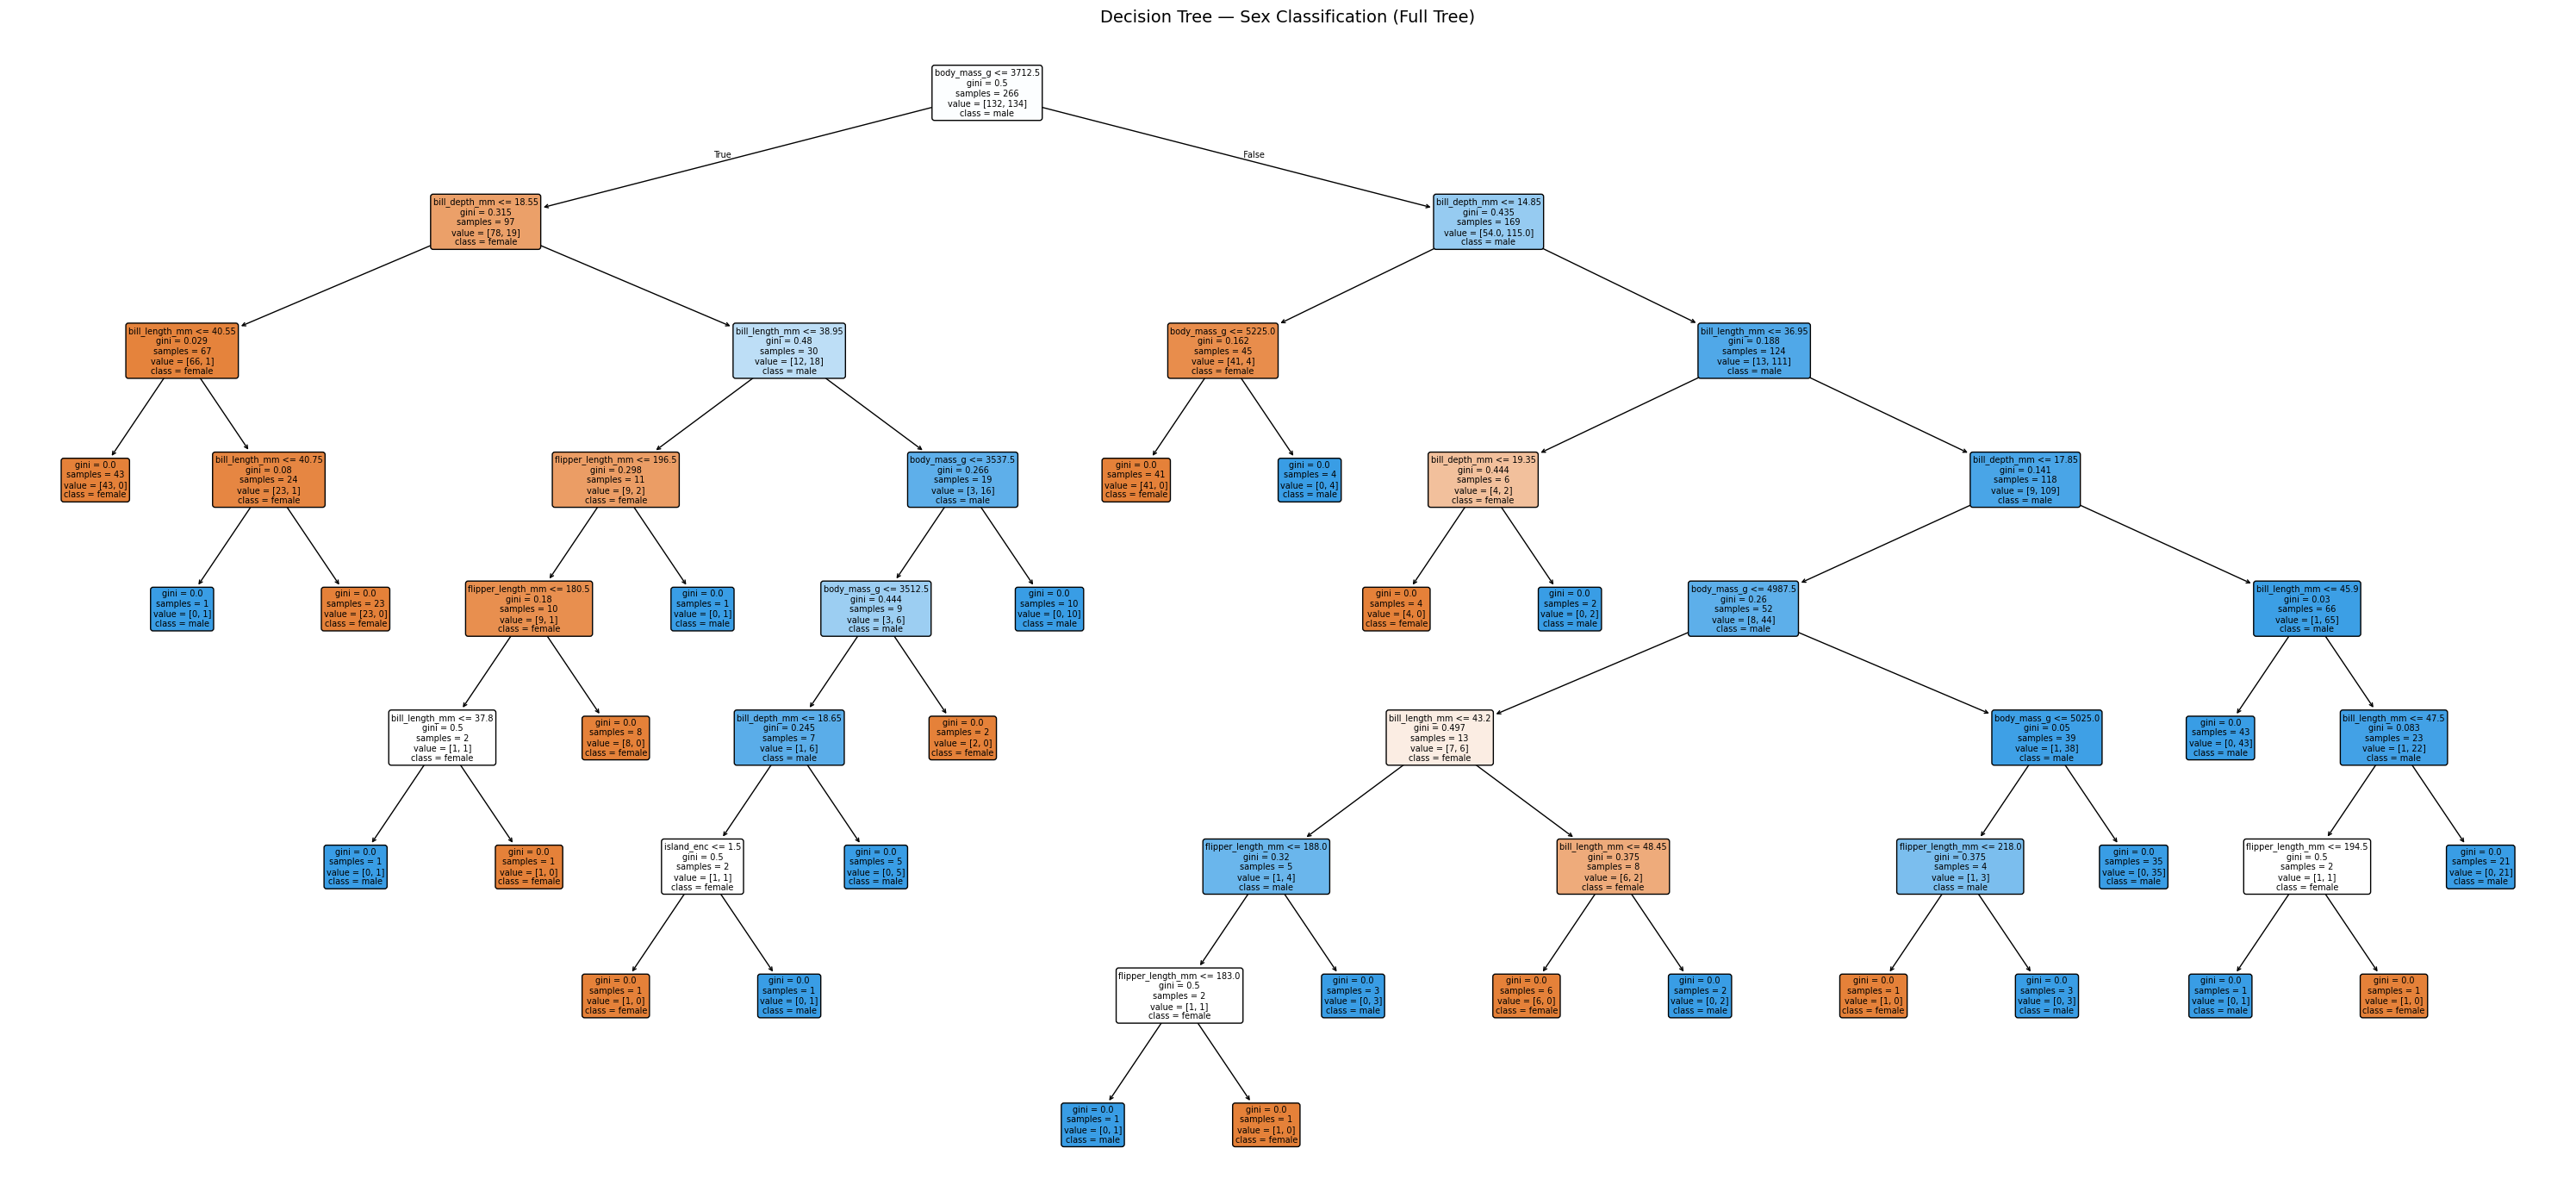

In [10]:
# Visualise the full sex tree
plt.figure(figsize=(30, 14))
plot_tree(
    dt_sex,
    feature_names=FEATURES,
    class_names=le_sex.classes_,
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Decision Tree — Sex Classification (Full Tree)", fontsize=14)
plt.tight_layout()
plt.show()

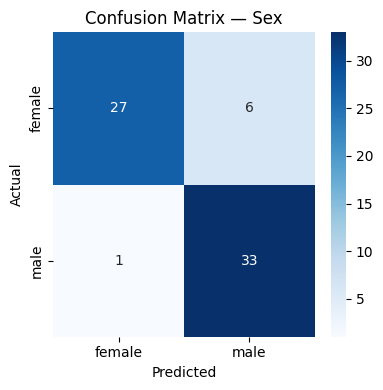

In [11]:
# Confusion matrix — Sex
cm2 = confusion_matrix(y_test2, y_pred_sex)
plt.figure(figsize=(4, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sex.classes_, yticklabels=le_sex.classes_)
plt.title("Confusion Matrix — Sex")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [12]:
# Text-format tree rules — sex
print("Sex Decision Tree Rules:")
print(export_text(dt_sex, feature_names=FEATURES))

Sex Decision Tree Rules:
|--- body_mass_g <= 3712.50
|   |--- bill_depth_mm <= 18.55
|   |   |--- bill_length_mm <= 40.55
|   |   |   |--- class: 0
|   |   |--- bill_length_mm >  40.55
|   |   |   |--- bill_length_mm <= 40.75
|   |   |   |   |--- class: 1
|   |   |   |--- bill_length_mm >  40.75
|   |   |   |   |--- class: 0
|   |--- bill_depth_mm >  18.55
|   |   |--- bill_length_mm <= 38.95
|   |   |   |--- flipper_length_mm <= 196.50
|   |   |   |   |--- flipper_length_mm <= 180.50
|   |   |   |   |   |--- bill_length_mm <= 37.80
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- bill_length_mm >  37.80
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- flipper_length_mm >  180.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- flipper_length_mm >  196.50
|   |   |   |   |--- class: 1
|   |   |--- bill_length_mm >  38.95
|   |   |   |--- body_mass_g <= 3537.50
|   |   |   |   |--- body_mass_g <= 3512.50
|   |   |   |   |   |--- bill_depth_mm <= 18.65
|   |   |

## 4. Pruned Trees (Problem 1c)
### (i) Maximum 4 levels including the root  →  max_depth = 3

In [13]:
# Species — max_depth = 3
dt_species_d4 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
dt_species_d4.fit(X_train, y_train)
y_pred_sp_d4 = dt_species_d4.predict(X_test)

print("Species | max_depth=3 (4 levels incl. root)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_sp_d4):.4f}")
print(f"  Leaves   : {dt_species_d4.get_n_leaves()}")
print(f"  Depth    : {dt_species_d4.get_depth()}")

# Sex — max_depth = 3
dt_sex_d4 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
dt_sex_d4.fit(X_train2, y_train2)
y_pred_sx_d4 = dt_sex_d4.predict(X_test2)

print("\nSex | max_depth=3 (4 levels incl. root)")
print(f"  Accuracy : {accuracy_score(y_test2, y_pred_sx_d4):.4f}")
print(f"  Leaves   : {dt_sex_d4.get_n_leaves()}")
print(f"  Depth    : {dt_sex_d4.get_depth()}")

Species | max_depth=3 (4 levels incl. root)
  Accuracy : 0.9403
  Leaves   : 7
  Depth    : 3

Sex | max_depth=3 (4 levels incl. root)
  Accuracy : 0.8507
  Leaves   : 8
  Depth    : 3


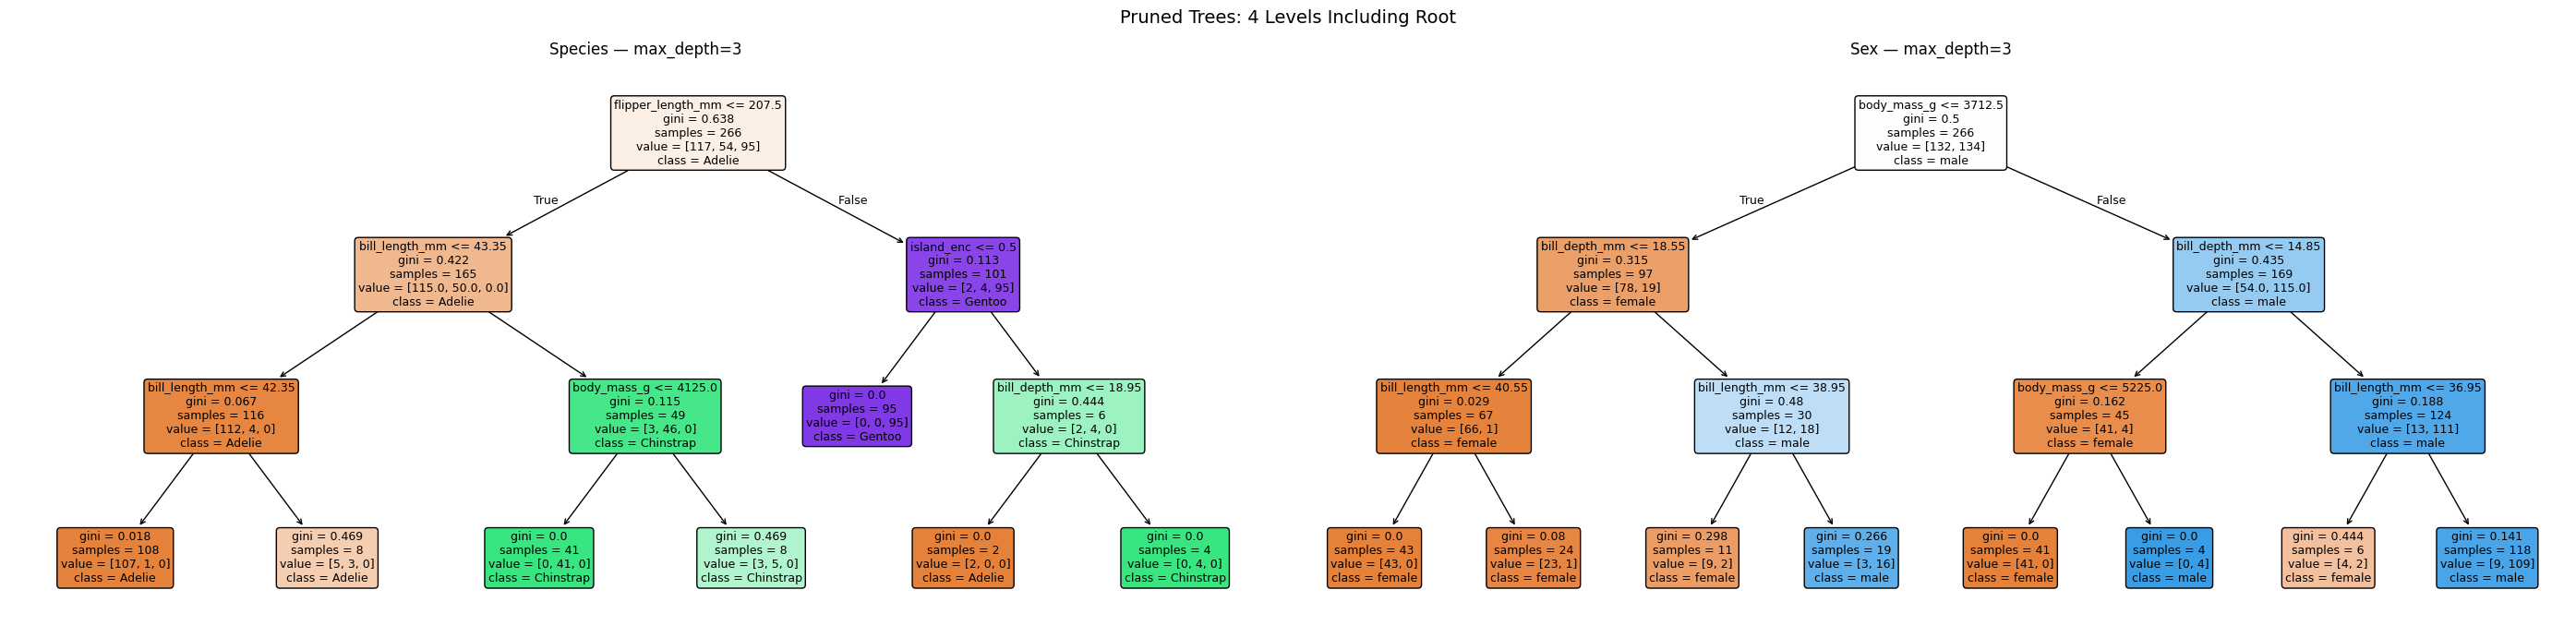

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(28, 7))

plot_tree(dt_species_d4, feature_names=FEATURES, class_names=le_species.classes_,
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Species — max_depth=3", fontsize=12)

plot_tree(dt_sex_d4, feature_names=FEATURES, class_names=le_sex.classes_,
          filled=True, rounded=True, fontsize=9, ax=axes[1])
axes[1].set_title("Sex — max_depth=3", fontsize=12)

plt.suptitle("Pruned Trees: 4 Levels Including Root", fontsize=14)
plt.tight_layout()
plt.show()

### (ii) Leaves containing at least 10 data points  →  min_samples_leaf = 10

In [15]:
# Species — min_samples_leaf = 10
dt_species_l10 = DecisionTreeClassifier(min_samples_leaf=10, random_state=SEED)
dt_species_l10.fit(X_train, y_train)
y_pred_sp_l10 = dt_species_l10.predict(X_test)

print("Species | min_samples_leaf=10")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_sp_l10):.4f}")
print(f"  Leaves   : {dt_species_l10.get_n_leaves()}")
print(f"  Depth    : {dt_species_l10.get_depth()}")

# Sex — min_samples_leaf = 10
dt_sex_l10 = DecisionTreeClassifier(min_samples_leaf=10, random_state=SEED)
dt_sex_l10.fit(X_train2, y_train2)
y_pred_sx_l10 = dt_sex_l10.predict(X_test2)

print("\nSex | min_samples_leaf=10")
print(f"  Accuracy : {accuracy_score(y_test2, y_pred_sx_l10):.4f}")
print(f"  Leaves   : {dt_sex_l10.get_n_leaves()}")
print(f"  Depth    : {dt_sex_l10.get_depth()}")

Species | min_samples_leaf=10
  Accuracy : 0.9403
  Leaves   : 7
  Depth    : 4

Sex | min_samples_leaf=10
  Accuracy : 0.8507
  Leaves   : 12
  Depth    : 6


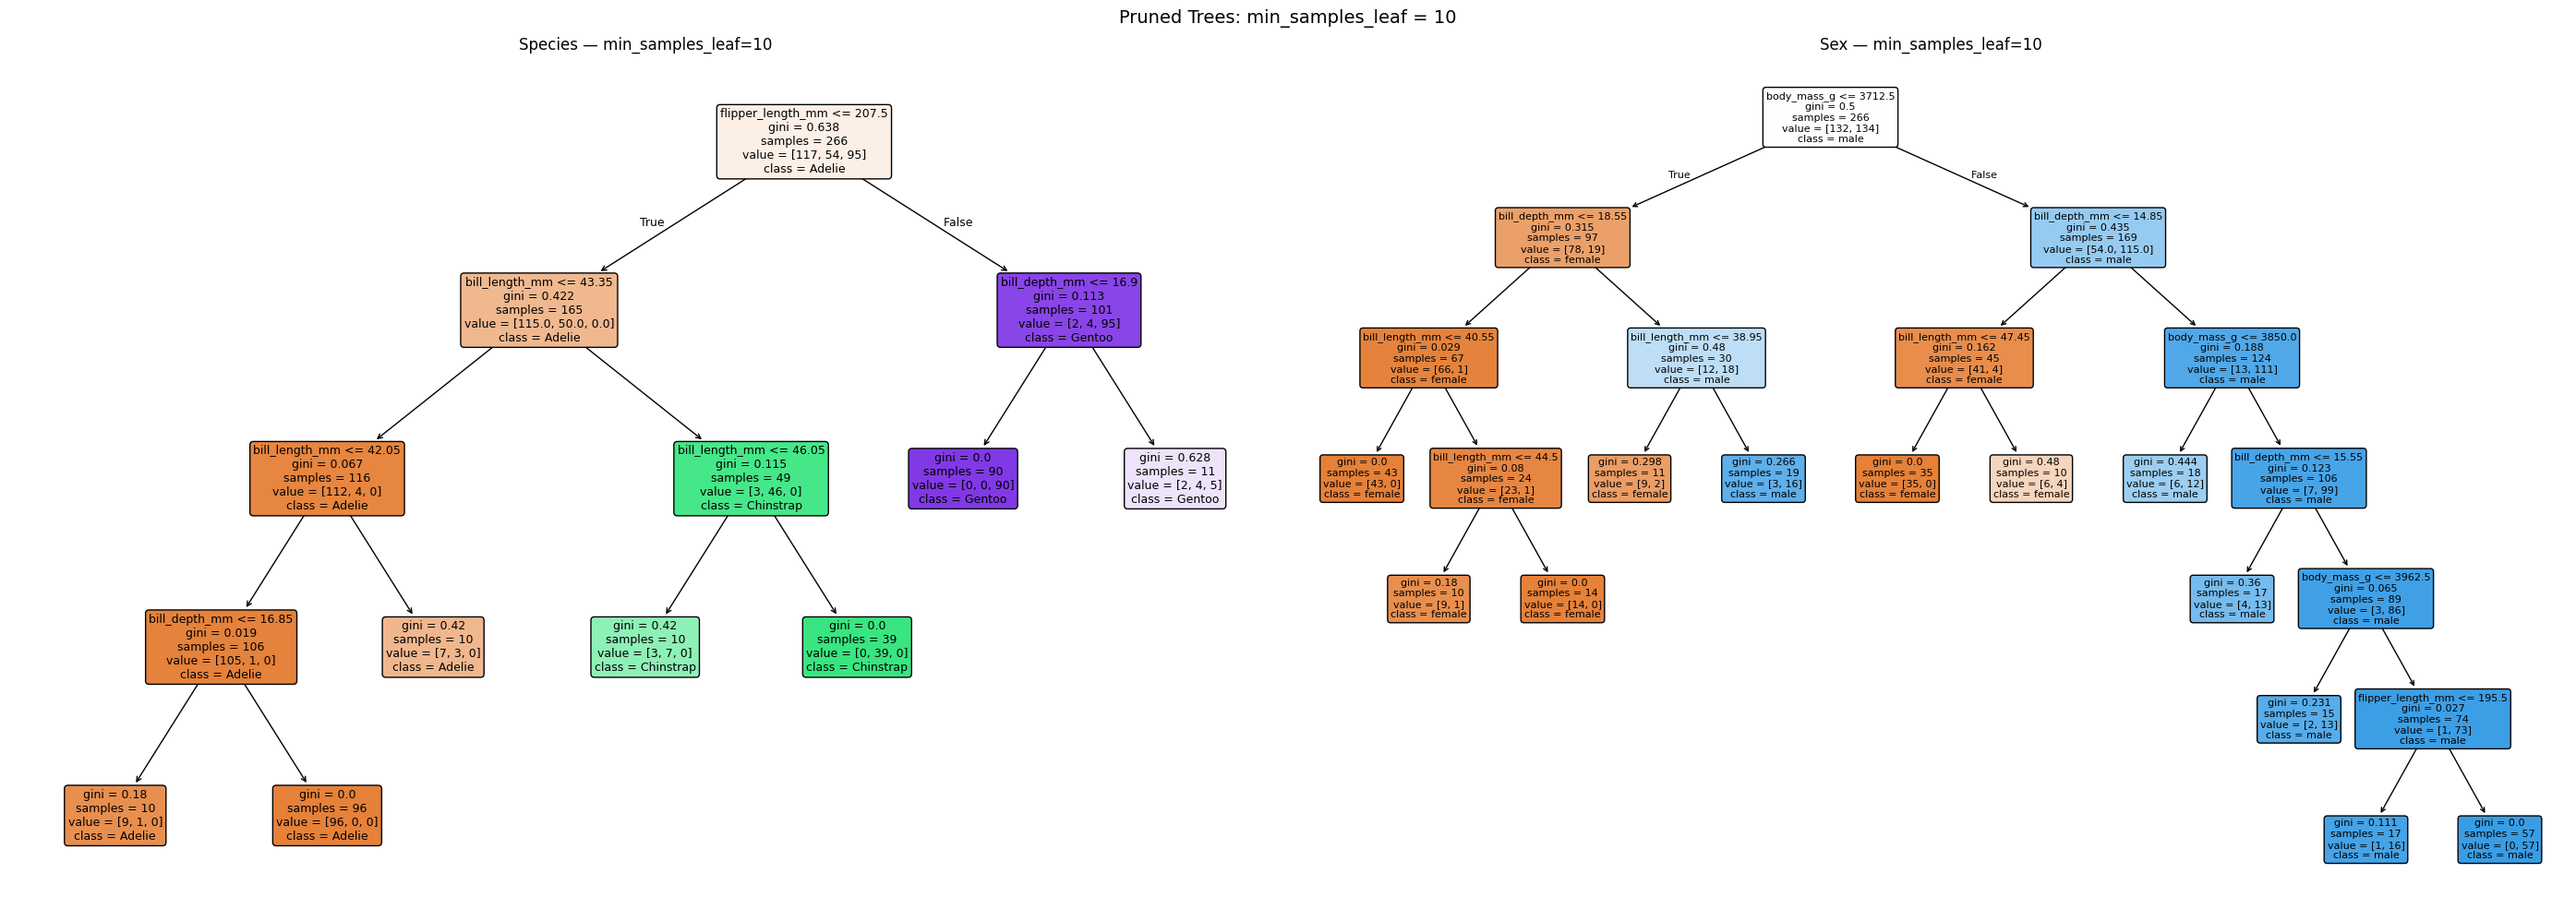

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(28, 10))

plot_tree(dt_species_l10, feature_names=FEATURES, class_names=le_species.classes_,
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Species — min_samples_leaf=10", fontsize=12)

plot_tree(dt_sex_l10, feature_names=FEATURES, class_names=le_sex.classes_,
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title("Sex — min_samples_leaf=10", fontsize=12)

plt.suptitle("Pruned Trees: min_samples_leaf = 10", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Summary Table

In [17]:
summary = {
    'Classifier': [
        'Species — Full',
        'Species — max_depth=3',
        'Species — min_samples_leaf=10',
        'Sex — Full',
        'Sex — max_depth=3',
        'Sex — min_samples_leaf=10',
    ],
    'Accuracy': [
        accuracy_score(y_test,  y_pred_species),
        accuracy_score(y_test,  y_pred_sp_d4),
        accuracy_score(y_test,  y_pred_sp_l10),
        accuracy_score(y_test2, y_pred_sex),
        accuracy_score(y_test2, y_pred_sx_d4),
        accuracy_score(y_test2, y_pred_sx_l10),
    ],
    'Leaves': [
        dt_species.get_n_leaves(),
        dt_species_d4.get_n_leaves(),
        dt_species_l10.get_n_leaves(),
        dt_sex.get_n_leaves(),
        dt_sex_d4.get_n_leaves(),
        dt_sex_l10.get_n_leaves(),
    ],
    'Depth': [
        dt_species.get_depth(),
        dt_species_d4.get_depth(),
        dt_species_l10.get_depth(),
        dt_sex.get_depth(),
        dt_sex_d4.get_depth(),
        dt_sex_l10.get_depth(),
    ],
}

summary_df = pd.DataFrame(summary)
summary_df['Accuracy'] = summary_df['Accuracy'].map('{:.4f}'.format)
print(summary_df.to_string(index=False))

                   Classifier Accuracy  Leaves  Depth
               Species — Full   0.9552      11      5
        Species — max_depth=3   0.9403       7      3
Species — min_samples_leaf=10   0.9403       7      4
                   Sex — Full   0.8955      28      8
            Sex — max_depth=3   0.8507       8      3
    Sex — min_samples_leaf=10   0.8507      12      6
